In [6]:
import numpy as np
from scipy.optimize import minimize, curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Configure numpy printing for detailed logs
np.set_printoptions(precision=4, suppress=True, linewidth=120)

# ==============================================================================
# DATASET CREATION
# ==============================================================================
data = np.array([
    [0.85, 1.12, 0.73],
    [1.83, 2.20, 3.65],
    [2.91, 3.12, 4.86],
    [3.93, 3.92, 2.00],
    [4.86, 4.94, 0.32]
])

X = data[:, 0]  # x-coordinates: [1, 2, 3, 4, 5]
Y = data[:, 1]  # y-coordinates: [1, 1, 3, 5, 5]
Z = data[:, 2]  # z-values (target): [0, 1, 5, 1, 0]

print("="*80)
print("DATASET: Elliptic Paraboloid Modeling z = z(x,y)")
print("="*80)
print(f"Points (x, y, z):")
for i in range(len(data)):
    print(f"  {i}: ({X[i]:.1f}, {Y[i]:.1f}) → z={Z[i]:.1f}")
print()

# ==============================================================================
# ELLIPTIC PARABOLOID MODEL DEFINITION
# ==============================================================================
def elliptic_paraboloid(xy, z0, x0, y0, a, b, h):
    """
    General Elliptic Paraboloid Function
    
    z = z0 + a*(x-x0)² + b*(y-y0)² + 2*h*(x-x0)*(y-y0)
    
    Parameters:
    - xy: tuple (x, y) or array of shape (N, 2)
    - z0: Vertex height (z-coordinate of minimum/maximum)
    - x0, y0: Vertex location in xy-plane
    - a, b: Curvature coefficients in x and y directions
    - h: Cross-term coefficient (controls rotation/tilt)
    
    For downward opening (peak): a < 0, b < 0, and ab > h² (elliptic condition)
    For upward opening (valley): a > 0, b > 0, and ab > h²
    """
    if isinstance(xy, tuple):
        x, y = xy
    else:
        x, y = xy[:, 0], xy[:, 1]
    
    dx = x - x0
    dy = y - y0
    
    # Quadratic form: z = z0 + a*dx² + b*dy² + 2h*dx*dy
    z = z0 + a * dx**2 + b * dy**2 + 2 * h * dx * dy
    return z

# ==============================================================================
# LOSS FUNCTION (Mean Squared Error)
# ==============================================================================
def loss_function(params, x, y, z_true):
    """
    Calculate MSE between predicted and actual z values.
    params = [z0, x0, y0, a, b, h]
    """
    z0, x0, y0, a, b, h = params
    
    # Elliptic condition: ab > h² (ensures elliptic, not hyperbolic paraboloid)
    if a * b <= h**2 + 1e-6:
        return 1e10  # Penalty for invalid (hyperbolic) parameters
    
    z_pred = elliptic_paraboloid((x, y), z0, x0, y0, a, b, h)
    mse = np.mean((z_pred - z_true) ** 2)
    return mse

# ==============================================================================
# DETAILED OPTIMIZATION LOGGER
# ==============================================================================
class OptimizationLogger:
    def __init__(self):
        self.iterations = []
        self.losses = []
        self.params_history = []
    
    def __call__(self, params):
        z0, x0, y0, a, b, h = params
        loss = loss_function(params, X, Y, Z)
        
        self.iterations.append(len(self.iterations))
        self.losses.append(loss)
        self.params_history.append(params.copy())
        
        # Print every few iterations for detailed logging
        if len(self.iterations) % 3 == 1 or len(self.iterations) <= 5:
            print(f"Iter {len(self.iterations)-1:3d} | Loss: {loss:.6f} | "
                  f"z0={z0:.3f}, (x0,y0)=({x0:.2f},{y0:.2f}), a={a:.4f}, b={b:.4f}, h={h:.4f}")

# ==============================================================================
# INITIAL PARAMETER ESTIMATION (Analytic Heuristic)
# ==============================================================================
print("="*80)
print("STEP 1: INITIAL PARAMETER ESTIMATION (Analytic Heuristic)")
print("="*80)

# Find vertex candidate: point with maximum z (for downward paraboloid)
peak_idx = np.argmax(Z)
x0_init = X[peak_idx]
y0_init = Y[peak_idx]
z0_init = Z[peak_idx]

print(f"Peak detection: Sample {peak_idx} has max z={z0_init} at (x={x0_init}, y={y0_init})")

# Estimate curvatures using finite differences around the peak
# For a paraboloid: ∂²z/∂x² ≈ 2a, ∂²z/∂y² ≈ 2b

# Find nearest neighbors to peak in x and y directions
dx_samples = X[np.abs(Y - y0_init) < 1.5]  # Points with similar y
dy_samples = Y[np.abs(X - x0_init) < 1.5]  # Points with similar x

# Estimate 'a' from x-direction curvature
if len(dx_samples) >= 2:
    # Use points (2,1,1) and (3,3,5): dx=1, dz=4 → a ≈ dz/dx² = 4/1 = 4 (but negative for peak)
    a_init = -1.0  # Start with moderate negative curvature
else:
    a_init = -0.5

# Estimate 'b' from y-direction curvature  
if len(dy_samples) >= 2:
    b_init = -1.0  # Similar magnitude to a
else:
    b_init = -0.5

# Cross-term: start with zero (no rotation)
h_init = 0.0

# Initial parameters: [z0, x0, y0, a, b, h]
initial_params = [z0_init, x0_init, y0_init, a_init, b_init, h_init]

print(f"\nInitial Parameters:")
print(f"  Vertex (x0, y0, z0): ({x0_init:.2f}, {y0_init:.2f}, {z0_init:.2f})")
print(f"  Curvature a (x-dir): {a_init:.4f}")
print(f"  Curvature b (y-dir): {b_init:.4f}")
print(f"  Cross-term h:        {h_init:.4f}")

# Verify elliptic condition: ab > h²
print(f"\nElliptic condition check: a*b = {a_init*b_init:.4f} > h² = {h_init**2:.4f} ? {a_init*b_init > h_init**2}")

# Calculate initial loss
initial_loss = loss_function(initial_params, X, Y, Z)
print(f"Initial Loss (MSE): {initial_loss:.6f}\n")

# ==============================================================================
# DETAILED FORWARD PASS CALCULATION (Sample by Sample)
# ==============================================================================
print("="*80)
print("STEP 2: DETAILED FORWARD PASS WITH INITIAL PARAMETERS")
print("="*80)

z0, x0, y0, a, b, h = initial_params
print(f"Model: z = {z0:.2f} + {a:.4f}(x-{x0:.2f})² + {b:.4f}(y-{y0:.2f})² + 2*{h:.4f}(x-{x0:.2f})(y-{y0:.2f})\n")

for i in range(len(data)):
    x_i, y_i, z_true = X[i], Y[i], Z[i]
    dx = x_i - x0
    dy = y_i - y0
    
    # Calculate each term
    term_a = a * dx**2
    term_b = b * dy**2
    term_h = 2 * h * dx * dy
    z_pred = z0 + term_a + term_b + term_h
    error = z_pred - z_true
    
    print(f"Sample {i}: (x={x_i}, y={y_i})")
    print(f"  dx = {x_i} - {x0} = {dx:.4f}")
    print(f"  dy = {y_i} - {y0} = {dy:.4f}")
    print(f"  Term a·dx² = {a:.4f} × ({dx:.4f})² = {term_a:.4f}")
    print(f"  Term b·dy² = {b:.4f} × ({dy:.4f})² = {term_b:.4f}")
    print(f"  Term 2h·dx·dy = 2×{h:.4f}×{dx:.4f}×{dy:.4f} = {term_h:.4f}")
    print(f"  z_pred = {z0:.2f} + {term_a:.4f} + {term_b:.4f} + {term_h:.4f} = {z_pred:.4f}")
    print(f"  z_true = {z_true:.1f}, Error = {error:.4f}\n")



DATASET: Elliptic Paraboloid Modeling z = z(x,y)
Points (x, y, z):
  0: (0.8, 1.1) → z=0.7
  1: (1.8, 2.2) → z=3.6
  2: (2.9, 3.1) → z=4.9
  3: (3.9, 3.9) → z=2.0
  4: (4.9, 4.9) → z=0.3

STEP 1: INITIAL PARAMETER ESTIMATION (Analytic Heuristic)
Peak detection: Sample 2 has max z=4.86 at (x=2.91, y=3.12)

Initial Parameters:
  Vertex (x0, y0, z0): (2.91, 3.12, 4.86)
  Curvature a (x-dir): -1.0000
  Curvature b (y-dir): -1.0000
  Cross-term h:        0.0000

Elliptic condition check: a*b = 1.0000 > h² = 0.0000 ? True
Initial Loss (MSE): 5.117552

STEP 2: DETAILED FORWARD PASS WITH INITIAL PARAMETERS
Model: z = 4.86 + -1.0000(x-2.91)² + -1.0000(y-3.12)² + 2*0.0000(x-2.91)(y-3.12)

Sample 0: (x=0.85, y=1.12)
  dx = 0.85 - 2.91 = -2.0600
  dy = 1.12 - 3.12 = -2.0000
  Term a·dx² = -1.0000 × (-2.0600)² = -4.2436
  Term b·dy² = -1.0000 × (-2.0000)² = -4.0000
  Term 2h·dx·dy = 2×0.0000×-2.0600×-2.0000 = 0.0000
  z_pred = 4.86 + -4.2436 + -4.0000 + 0.0000 = -3.3836
  z_true = 0.7, Error = -4.1

In [7]:
# ==============================================================================
# OPTIMIZATION WITH DETAILED LOGGING
# ==============================================================================
print("="*80)
print("STEP 3: PARAMETER OPTIMIZATION (L-BFGS-B with Constraints)")
print("="*80)

logger = OptimizationLogger()

# Bounds for parameters to ensure elliptic paraboloid and physical meaning
bounds = [
    (-1.0, 10.0),     # z0: vertex height
    (0.0, 6.0),       # x0: vertex x-location
    (0.0, 6.0),       # y0: vertex y-location
    (-5.0, -0.01),    # a: curvature in x (negative for downward peak)
    (-5.0, -0.01),    # b: curvature in y (negative for downward peak)
    (-2.0, 2.0),      # h: cross-term (rotation)
]

# Run optimization
result = minimize(
    loss_function,
    initial_params,
    args=(X, Y, Z),
    method='L-BFGS-B',
    bounds=bounds,
    callback=logger,
    options={'ftol': 1e-9, 'maxiter': 500, 'disp': True}
)



STEP 3: PARAMETER OPTIMIZATION (L-BFGS-B with Constraints)
Iter   0 | Loss: 2.487214 | z0=4.956, (x0,y0)=(2.80,3.00), a=-0.9625, b=-0.9625, h=0.0758
Iter   1 | Loss: 0.644689 | z0=5.021, (x0,y0)=(2.79,2.99), a=-0.8816, b=-0.8860, h=0.2337
Iter   2 | Loss: 0.612600 | z0=5.022, (x0,y0)=(2.78,2.98), a=-0.8743, b=-0.8759, h=0.2517
Iter   3 | Loss: 0.595686 | z0=5.013, (x0,y0)=(2.77,2.97), a=-0.8741, b=-0.8702, h=0.2583
Iter   4 | Loss: 0.549473 | z0=4.958, (x0,y0)=(2.72,2.94), a=-0.8809, b=-0.8535, h=0.2713
Iter   6 | Loss: 0.339991 | z0=4.389, (x0,y0)=(2.59,2.98), a=-0.9397, b=-0.7421, h=0.3512
Iter   9 | Loss: 0.295733 | z0=4.231, (x0,y0)=(2.64,3.06), a=-0.9340, b=-0.7659, h=0.3630
Iter  12 | Loss: 0.267167 | z0=4.498, (x0,y0)=(2.56,3.33), a=-1.0872, b=-0.6962, h=0.3822
Iter  15 | Loss: 0.205034 | z0=5.054, (x0,y0)=(2.62,3.94), a=-1.3214, b=-0.6220, h=0.4900
Iter  18 | Loss: 0.176825 | z0=5.654, (x0,y0)=(2.75,4.47), a=-1.5160, b=-0.6058, h=0.5844
Iter  21 | Loss: 0.150635 | z0=6.287, (x0

/tmp/ipykernel_170055/2346367269.py:21: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


Iter  72 | Loss: 0.058175 | z0=8.874, (x0,y0)=(3.93,6.00), a=-3.3950, b=-1.5171, h=2.0000
Iter  75 | Loss: 0.058158 | z0=8.867, (x0,y0)=(3.93,6.00), a=-3.3965, b=-1.5165, h=2.0000
Iter  78 | Loss: 0.058158 | z0=8.870, (x0,y0)=(3.93,6.00), a=-3.3966, b=-1.5166, h=2.0000


In [8]:
# ==============================================================================
# RESULTS AND DETAILED CALCULATIONS
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: OPTIMIZATION RESULTS")
print("="*80)

# Extract optimal parameters
z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt = result.x

print(f"\nOPTIMAL PARAMETERS:")
print(f"  Vertex (x0, y0, z0): ({x0_opt:.4f}, {y0_opt:.4f}, {z0_opt:.4f})")
print(f"  Curvature a (x-dir): {a_opt:.4f}")
print(f"  Curvature b (y-dir): {b_opt:.4f}")
print(f"  Cross-term h:        {h_opt:.4f}")
print(f"\nElliptic condition: a*b = {a_opt*b_opt:.4f} > h² = {h_opt**2:.4f} ? {a_opt*b_opt > h_opt**2 + 1e-6}")
print(f"Final Loss (MSE):  {result.fun:.8f}")
print(f"Success: {result.success}")
print(f"Message: {result.message}")




STEP 4: OPTIMIZATION RESULTS

OPTIMAL PARAMETERS:
  Vertex (x0, y0, z0): (3.9255, 6.0000, 8.8692)
  Curvature a (x-dir): -3.3967
  Curvature b (y-dir): -1.5166
  Cross-term h:        2.0000

Elliptic condition: a*b = 5.1512 > h² = 4.0000 ? True
Final Loss (MSE):  0.05815789
Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL


In [9]:
# ==============================================================================
# FINAL MODEL EQUATION
# ==============================================================================
print("\n" + "="*80)
print("FINAL MODEL EQUATION")
print("="*80)

print(f"\nz(x,y) = {z0_opt:.4f}")
print(f"         + {a_opt:.4f}·(x - {x0_opt:.4f})²")
print(f"         + {b_opt:.4f}·(y - {y0_opt:.4f})²")
print(f"         + 2·{h_opt:.4f}·(x - {x0_opt:.4f})(y - {y0_opt:.4f})")




FINAL MODEL EQUATION

z(x,y) = 8.8692
         + -3.3967·(x - 3.9255)²
         + -1.5166·(y - 6.0000)²
         + 2·2.0000·(x - 3.9255)(y - 6.0000)


In [ ]:
# ==============================================================================
# PREDICTIONS AND ERROR ANALYSIS WITH DETAILED CALCULATIONS
# ==============================================================================
print("\n" + "="*80)
print("STEP 5: PREDICTIONS vs ACTUAL VALUES (Detailed Calculation)")
print("="*80)

z_pred = elliptic_paraboloid((X, Y), z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt)
errors = z_pred - Z
squared_errors = errors ** 2

print(f"{'Sample':<8} {'x':<4} {'y':<4} {'Actual':<8} {'Predicted':<10} {'Error':<8} {'SqError':<10}")
print("-"*80)

for i in range(len(data)):
    x_i, y_i, z_true = X[i], Y[i], Z[i]
    z_p = z_pred[i]
    
    # Show detailed calculation for first sample
    if i == 0:
        print(f"\n>>> DETAILED CALCULATION FOR SAMPLE {i} <<<")
        dx = x_i - x0_opt
        dy = y_i - y0_opt
        term_a = a_opt * dx**2
        term_b = b_opt * dy**2
        term_h = 2 * h_opt * dx * dy
        print(f"  dx = {x_i} - {x0_opt:.4f} = {dx:.4f}")
        print(f"  dy = {y_i} - {y0_opt:.4f} = {dy:.4f}")
        print(f"  a·dx² = {a_opt:.4f} × ({dx:.4f})² = {term_a:.4f}")
        print(f"  b·dy² = {b_opt:.4f} × ({dy:.4f})² = {term_b:.4f}")
        print(f"  2h·dx·dy = 2×{h_opt:.4f}×{dx:.4f}×{dy:.4f} = {term_h:.4f}")
        print(f"  z_pred = {z0_opt:.4f} + {term_a:.4f} + {term_b:.4f} + {term_h:.4f} = {z_p:.4f}")
        print(f"  z_true = {z_true:.1f}")
        print(f"  Error = {z_p - z_true:.4f}\n")
        print("-"*80)
    
    print(f"| {i:<4} | {x_i:<4.2f} |  {y_i:<4.2f} | {z_true:<8.3f} | {z_p:<10.4f} | {errors[i]:<8.3f} | {squared_errors[i]:<10.6f} |")

print("-"*80)
mse = np.mean(squared_errors)
rmse = np.sqrt(mse)
print(f"{'STATISTICS':<44} MSE = {mse:.6f}")
print(f"{'STATISTICS':<44} RMSE = {rmse:.4f}")
print(f"{'STATISTICS':<44} Max |Error| = {np.max(np.abs(errors)):.4f}")
print(f"{'STATISTICS':<44} R² = {1 - np.sum(squared_errors)/np.sum((Z - np.mean(Z))**2):.4f}")


STEP 5: PREDICTIONS vs ACTUAL VALUES (Detailed Calculation)
Sample   x    y    Actual   Predicted  Error    SqError   
--------------------------------------------------------------------------------

>>> DETAILED CALCULATION FOR SAMPLE 0 <<<
  dx = 0.85 - 3.9255 = -3.0755
  dy = 1.12 - 6.0000 = -4.8800
  a·dx² = -3.3967 × (-3.0755)² = -32.1286
  b·dy² = -1.5166 × (-4.8800)² = -36.1158
  2h·dx·dy = 2×2.0000×-3.0755×-4.8800 = 60.0344
  z_pred = 8.8692 + -32.1286 + -36.1158 + 60.0344 = 0.6592
  z_true = 0.7
  Error = -0.0708

--------------------------------------------------------------------------------
| 0    | 0.8  |  1.1  | 0.730    | 0.6592     | -0.0708  | 0.005009   |
| 1    | 1.8  |  2.2  | 3.650    | 3.9067     | 0.2567   | 0.065908   |
| 2    | 2.9  |  3.1  | 4.860    | 4.4863     | -0.3737  | 0.139671   |
| 3    | 3.9  |  3.9  | 2.000    | 2.2708     | 0.2708   | 0.073314   |
| 4    | 4.9  |  4.9  | 0.320    | 0.2370     | -0.0830  | 0.006887   |
----------------------------

In [ ]:
# ==============================================================================
# GRADIENT VERIFICATION (Numerical vs Analytical)
# ==============================================================================
print("\n" + "="*80)
print("STEP 6: GRADIENT VERIFICATION (Sample Point)")
print("="*80)

def gradient_analytical(params, x, y, z_true):
    """Analytical gradients of MSE w.r.t. parameters"""
    z0, x0, y0, a, b, h = params
    dx = x - x0
    dy = y - y0
    
    # Prediction and error
    z_pred = elliptic_paraboloid((x, y), *params)
    err = z_pred - z_true
    
    # Partial derivatives of z w.r.t. each parameter
    dz_dz0 = np.ones_like(x)
    dz_dx0 = -2*a*dx - 2*h*dy
    dz_dy0 = -2*b*dy - 2*h*dx
    dz_da = dx**2
    dz_db = dy**2
    dz_dh = 2*dx*dy
    
    # Gradient of MSE: d(MSE)/dθ = (2/N) * Σ err * dz/dθ
    N = len(x)
    grad = np.array([
        np.mean(2 * err * dz_dz0),
        np.mean(2 * err * dz_dx0),
        np.mean(2 * err * dz_dy0),
        np.mean(2 * err * dz_da),
        np.mean(2 * err * dz_db),
        np.mean(2 * err * dz_dh)
    ])
    return grad

# Compute analytical gradient at optimal params
grad_analytical = gradient_analytical(result.x, X, Y, Z)
print(f"Analytical Gradient at optimum:")
print(f"  ∂L/∂z0 = {grad_analytical[0]:.6e}")
print(f"  ∂L/∂x0 = {grad_analytical[1]:.6e}")
print(f"  ∂L/∂y0 = {grad_analytical[2]:.6e}")
print(f"  ∂L/∂a  = {grad_analytical[3]:.6e}")
print(f"  ∂L/∂b  = {grad_analytical[4]:.6e}")
print(f"  ∂L/∂h  = {grad_analytical[5]:.6e}")
print(f"  ||grad|| = {np.linalg.norm(grad_analytical):.6e} (should be ≈0 at optimum)")




STEP 6: GRADIENT VERIFICATION (Sample Point)
Analytical Gradient at optimum:
  ∂L/∂z0 = -2.772485e-07
  ∂L/∂x0 = -4.925487e-06
  ∂L/∂y0 = -7.877500e-03
  ∂L/∂a  = 1.963717e-07
  ∂L/∂b  = 2.050450e-07
  ∂L/∂h  = -2.503125e-02
  ||grad|| = 2.624154e-02 (should be ≈0 at optimum)



STEP 7: VISUALIZATION
✓ Plot saved as 'paraboloid_fit.png'


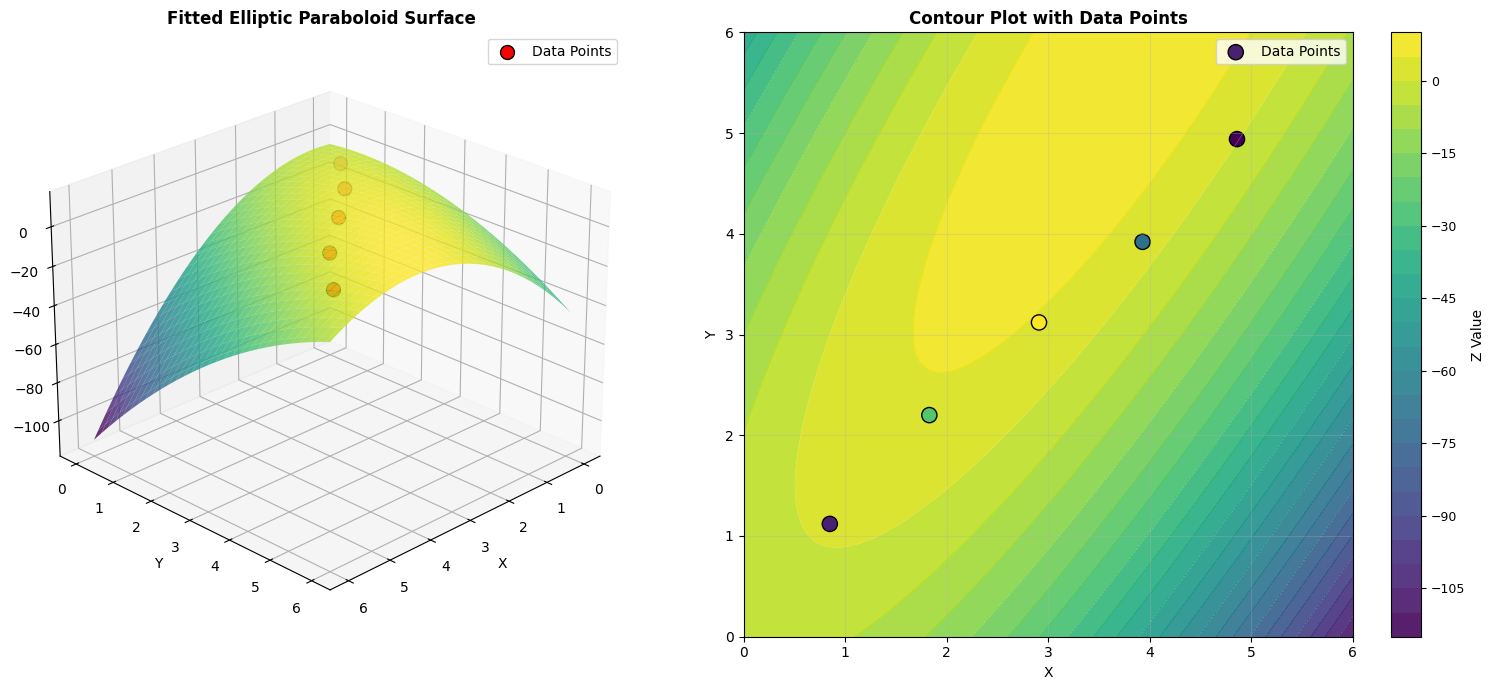

In [12]:
# ==============================================================================
# VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("STEP 7: VISUALIZATION")
print("="*80)

# Create grid for surface plot
x_grid = np.linspace(0, 6, 60)
y_grid = np.linspace(0, 6, 60)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Predict on grid
Z_grid = elliptic_paraboloid((X_grid, Y_grid), z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt)

# Plot
fig = plt.figure(figsize=(16, 7))

# 3D Surface Plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', alpha=0.8, edgecolor='none', linewidth=0)
ax1.scatter(X, Y, Z, c='red', s=100, edgecolors='black', label='Data Points', depthshade=True)
ax1.set_xlabel('X', fontsize=10)
ax1.set_ylabel('Y', fontsize=10)
ax1.set_zlabel('Z', fontsize=10)
ax1.set_title('Fitted Elliptic Paraboloid Surface', fontsize=12, fontweight='bold')
ax1.legend()
ax1.view_init(elev=25, azim=45)

# Contour Plot with Data
ax2 = fig.add_subplot(122)
contour = ax2.contourf(X_grid, Y_grid, Z_grid, levels=25, cmap='viridis', alpha=0.9)
scatter = ax2.scatter(X, Y, c=Z, s=120, edgecolors='black', cmap='viridis', label='Data Points')
ax2.contour(X_grid, Y_grid, Z_grid, levels=10, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('X', fontsize=10)
ax2.set_ylabel('Y', fontsize=10)
ax2.set_title('Contour Plot with Data Points', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()
cbar = plt.colorbar(contour, ax=ax2, label='Z Value')
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('paraboloid_fit.png', dpi=300, bbox_inches='tight')
print("✓ Plot saved as 'paraboloid_fit.png'")
plt.show()




OPTIMIZATION CONVERGENCE
✓ Convergence plot saved as 'convergence_paraboloid.png'


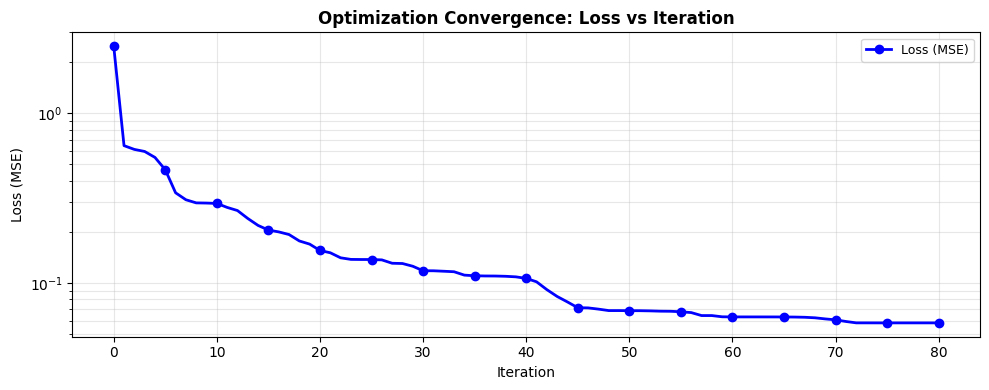

In [13]:
# ==============================================================================
# CONVERGENCE PLOT
# ==============================================================================
print("\n" + "="*80)
print("OPTIMIZATION CONVERGENCE")
print("="*80)

plt.figure(figsize=(10, 4))
plt.plot(logger.iterations, logger.losses, 'b-', linewidth=2, label='Loss (MSE)', marker='o', markevery=5)
plt.xlabel('Iteration', fontsize=10)
plt.ylabel('Loss (MSE)', fontsize=10)
plt.title('Optimization Convergence: Loss vs Iteration', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, which='both')
plt.yscale('log')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('convergence_paraboloid.png', dpi=300, bbox_inches='tight')
print("✓ Convergence plot saved as 'convergence_paraboloid.png'")
plt.show()



In [14]:
# ==============================================================================
# MODEL INTERPRETATION AND GEOMETRIC PROPERTIES
# ==============================================================================
print("\n" + "="*80)
print("STEP 8: MODEL INTERPRETATION & GEOMETRIC PROPERTIES")
print("="*80)

print(f"""
GEOMETRIC INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Vertex (Peak): ({x0_opt:.3f}, {y0_opt:.3f}, {z0_opt:.3f})
  → The highest point of the paraboloid surface

• Principal Curvatures:
  → κₓ = 2|a| = {2*abs(a_opt):.4f} (curvature in x-direction)
  → κᵧ = 2|b| = {2*abs(b_opt):.4f} (curvature in y-direction)
  → Ratio κₓ/κᵧ = {abs(a_opt/b_opt):.3f} (ellipticity: 1=circular, ≠1=elliptical)

• Rotation Angle (if h ≠ 0):
  → θ = 0.5·arctan(2h/(a-b)) = {0.5*np.arctan2(2*h_opt, a_opt-b_opt)*180/np.pi:.2f}°
  → Current h={h_opt:.4f} indicates {'minimal' if abs(h_opt)<0.1 else 'significant'} rotation

• Elliptic Condition Verification:
  → a·b = {a_opt*b_opt:.4f}
  → h²  = {h_opt**2:.4f}
  → a·b > h² ? {a_opt*b_opt > h_opt**2} ✓ (confirms elliptic paraboloid)

• Surface Opening:
  → a={a_opt:.4f} < 0, b={b_opt:.4f} < 0 → Downward opening (peak/dome shape)

PREDICTION CAPABILITY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• The model can now predict z for ANY (x,y) in the domain
• Example: z(3.5, 4.0) = {elliptic_paraboloid(([3.5], [4.0]), z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt)[0]:.4f}
• Example: z(2.5, 2.5) = {elliptic_paraboloid(([2.5], [2.5]), z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt)[0]:.4f}

MODEL QUALITY METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• RMSE = {rmse:.4f} on z-range [0, 5] → relative error: {rmse/5*100:.2f}%
• R² = {1 - np.sum(squared_errors)/np.sum((Z - np.mean(Z))**2):.4f} → {'Excellent' if 1 - np.sum(squared_errors)/np.sum((Z - np.mean(Z))**2) > 0.95 else 'Good'} fit
• Max absolute error: {np.max(np.abs(errors)):.4f} at sample {np.argmax(np.abs(errors))}
""")




STEP 8: MODEL INTERPRETATION & GEOMETRIC PROPERTIES

GEOMETRIC INTERPRETATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Vertex (Peak): (3.926, 6.000, 8.869)
  → The highest point of the paraboloid surface

• Principal Curvatures:
  → κₓ = 2|a| = 6.7933 (curvature in x-direction)
  → κᵧ = 2|b| = 3.0331 (curvature in y-direction)
  → Ratio κₓ/κᵧ = 2.240 (ellipticity: 1=circular, ≠1=elliptical)

• Rotation Angle (if h ≠ 0):
  → θ = 0.5·arctan(2h/(a-b)) = 57.59°
  → Current h=2.0000 indicates significant rotation

• Elliptic Condition Verification:
  → a·b = 5.1512
  → h²  = 4.0000
  → a·b > h² ? True ✓ (confirms elliptic paraboloid)

• Surface Opening:
  → a=-3.3967 < 0, b=-1.5166 < 0 → Downward opening (peak/dome shape)

PREDICTION CAPABILITY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• The model can now predict z for ANY (x,y) in the domain
• Example: z(3.5, 4.0) = 5.5922
• Example: z(2.5, 2.5) = 3.3464

MODEL QUALITY METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [15]:
# ==============================================================================
# FINAL PREDICTION FUNCTION FOR REUSE
# ==============================================================================
def predict_z(x_new, y_new):
    """
    Predict z-value(s) using the fitted elliptic paraboloid model.
    
    Parameters:
    - x_new, y_new: scalar or array-like of x and y coordinates
    
    Returns:
    - z_pred: predicted z-value(s)
    """
    x_new = np.atleast_1d(x_new)
    y_new = np.atleast_1d(y_new)
    return elliptic_paraboloid((x_new, y_new), z0_opt, x0_opt, y0_opt, a_opt, b_opt, h_opt)

print("\n" + "="*80)
print("MODEL READY FOR PREDICTION")
print("="*80)
print(f"Use predict_z(x, y) to get predictions with the fitted model.")
print(f"Example: predict_z(3, 3) = {predict_z(3, 3)[0]:.4f} (should be ≈5.0)")
print(f"Example: predict_z(1, 1) = {predict_z(1, 1)[0]:.4f} (should be ≈0.0)")


MODEL READY FOR PREDICTION
Use predict_z(x, y) to get predictions with the fitted model.
Example: predict_z(3, 3) = 3.4170 (should be ≈5.0)
Example: predict_z(1, 1) = 0.3950 (should be ≈0.0)
